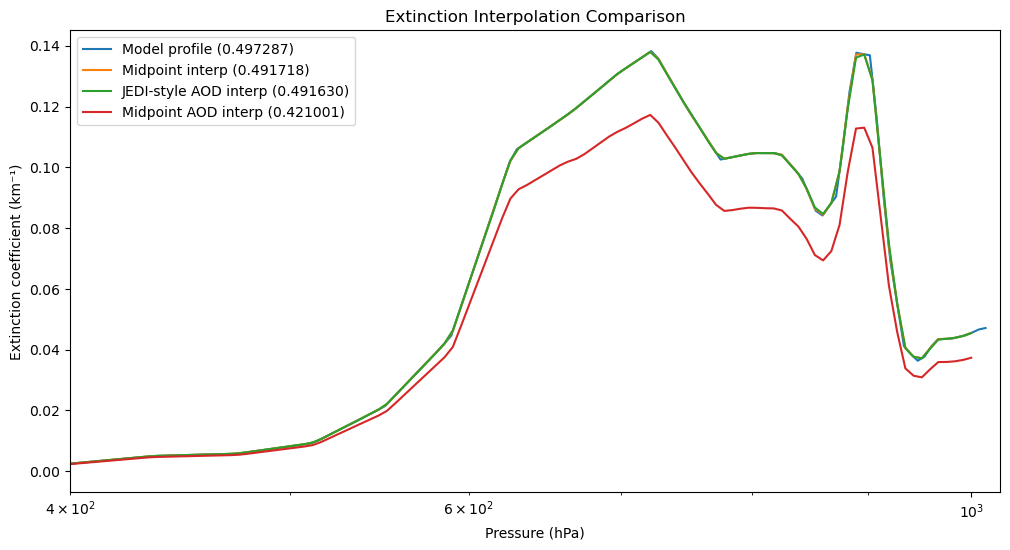

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- Physical constants ---
GRAV = 9.80665  # m/s^2
M_DRY = 28.9647e-3  # kg/mol
R_UNIV = 8.314462618  # J/mol/K
MISSING_VALUE = np.nan  # or any large sentinel value


# =====================================================
# Helper: compute interpolation weights
# =====================================================
def vert_interp_weights(vec, obl):
    """
    Python translation of JEDI-style Fortran vert_interp_weights.

    Parameters
    ----------
    vec : array_like
        Structured vertical coordinate (e.g., pressure interfaces), length nlev
    obl : float
        Observation level (same units as vec)

    Returns
    -------
    wi : int
        Base index (0-based, corresponds to Fortran wi)
    wf : float
        Weight (fraction toward vec[wi])
    """
    nlev = len(vec)

    # Handle missing
    if np.isnan(obl):
        return np.nan, np.nan

    # Pressure increasing with index
    if vec[0] < vec[-1]:
        if obl < vec[0]:
            wi, wf = 0, 1.0
        elif obl > vec[-1]:
            wi, wf = nlev - 2, 0.0
        else:
            wi = None
            for k in range(nlev - 1):
                if vec[k] <= obl <= vec[k + 1]:
                    wi = k
                    break
            wf = (vec[wi + 1] - obl) / (vec[wi + 1] - vec[wi])
    else:  # Pressure decreases with index
        if obl > vec[0]:
            wi, wf = 0, 1.0
        elif obl < vec[-1]:
            wi, wf = nlev - 2, 0.0
        else:
            wi = None
            for k in range(nlev - 1):
                if vec[k + 1] <= obl <= vec[k]:
                    wi = k
                    break
            wf = (vec[wi + 1] - obl) / (vec[wi + 1] - vec[wi])

    return wi, wf


# =====================================================
# JEDI-style interpolation (from Fortran logic)
# =====================================================
def interpolate_extinction_jedi_style(beta_model, pmod_int, pobs_int):
    """
    JEDI-style vertical interpolation of extinction coefficient (beta) at model midpoints
    to observation layers defined by interface pressures.

    Parameters
    ----------
    beta_model : ndarray, shape (n_model,)
        Extinction coefficient at model midpoints (m^-1)
    pmod_mid : ndarray, shape (n_model,)
        Pressure at model midpoints (Pa), decreasing or increasing order
    pobs_int : ndarray, shape (n_obs+1,)
        Pressure at observation interfaces (Pa), same ordering (top->bottom or bottom->top)

    Returns
    -------
    beta_obs : ndarray, shape (n_obs,)
        Extinction coefficient interpolated to observation layer midpoints (m^-1)
    """
    n_obs = len(pobs_int) - 1
    beta_obs = np.zeros(n_obs)

    for k in range(n_obs):
        wi_a, wf_a = vert_interp_weights(pmod_int, pobs_int[k])
        wi_b, wf_b = vert_interp_weights(pmod_int, pobs_int[k + 1])

        if wi_a < wi_b:
            # Multiple model layers within an obs layer
            val = beta_model[wi_a] * wf_a
            for j in range(wi_a + 1, wi_b):
                val += beta_model[j]
            val += beta_model[wi_b] * (1.0 - wf_b)
            beta_obs[k] = val / (wi_b - wi_a + 1 - wf_a - (1.0 - wf_b))

        elif wi_a == wi_b:
            # Observation layer lies within one model layer
            val = beta_model[wi_a] * (wf_a - wf_b)
            beta_obs[k] = val / (wf_a - wf_b)

        else:
            raise ValueError("Inverted pressure coordinate (check ordering).")

    return beta_obs

def interpolate_beta_from_tau_jedi_style(tau_model, pmod_int, pobs_int, dz_model, dz_obs):
    """
    Interpolate extinction coefficient from layer optical depth using JEDI-style layer weights.

    Parameters
    ----------
    tau_model : ndarray, shape (n_model,)
        Optical depth of each model layer (dimensionless)
    pmod_int : ndarray, shape (n_model+1,)
        Pressure at model interfaces (Pa)
    pobs_int : ndarray, shape (n_obs+1,)
        Pressure at observation interfaces (Pa)
    dz_model : ndarray, shape (n_model,)
        Geometric thickness of model layers (m)
    dz_obs : ndarray, shape (n_obs,)
        Geometric thickness of observation layers (m)

    Returns
    -------
    beta_obs : ndarray, shape (n_obs,)
        Extinction coefficient interpolated to observation layers (m^-1)
    """

    n_obs = len(pobs_int) - 1
    beta_obs = np.zeros(n_obs)

    # Compute model layer mean extinction coefficient (tau / dz)
    beta_model = tau_model / dz_model

    for k in range(n_obs):
        # Determine interpolation weights for top and bottom obs interfaces
        wi_a, wf_a = vert_interp_weights(pmod_int, pobs_int[k])
        wi_b, wf_b = vert_interp_weights(pmod_int, pobs_int[k + 1])

        if wi_a < wi_b:
            # Multiple model layers overlap this observation layer
            val = beta_model[wi_a] * wf_a * dz_model[wi_a]  # partial top layer
            for j in range(wi_a + 1, wi_b):
                val += beta_model[j] * dz_model[j]  # full middle layers
            val += beta_model[wi_b] * (1.0 - wf_b) * dz_model[wi_b]  # partial bottom layer
            # Divide by obs thickness to get mean extinction coefficient
            beta_obs[k] = val / dz_obs[k]

        elif wi_a == wi_b:
            # Observation layer lies within a single model layer
            # linear weight between interfaces
            val = beta_model[wi_a] * ((wf_a - wf_b) * dz_model[wi_a])
            beta_obs[k] = val / dz_obs[k]

        else:
            raise ValueError("Pressure coordinate orientation inconsistent.")

    return beta_obs
    
# =====================================================
# Midpoint interpolation
# =====================================================
def midpoint_interpolation(pmod_mid, beta_model, pobs_mid):
    beta_obs = np.interp(np.log(pobs_mid), np.log(pmod_mid), beta_model)
    return beta_obs

def estimate_obs_layer_thickness(pmod_mid, dz_model, pobs_mid):
    """
    Estimate geometric thickness (Δz) for observation layers
    from model midpoint pressures and thicknesses.

    Parameters
    ----------
    pmod_mid : ndarray, shape (N,)
        Model midpoint pressures (Pa), increasing downward.
    dz_model : ndarray, shape (N,)
        Model layer thicknesses (m), positive downward.
    pobs_mid : ndarray, shape (M,)
        Observation midpoint pressures (Pa), increasing downward.

    Returns
    -------
    dz_obs : ndarray, shape (M,)
        Estimated layer thicknesses for observation layers (m).
    """

    pmod_mid = np.asarray(pmod_mid)
    dz_model = np.asarray(dz_model)
    pobs_mid = np.asarray(pobs_mid)

    # Ensure positive pressures
    assert np.all(pmod_mid > 0), "Model pressures must be positive"

    # Compute scale height H = dz / d(ln p)
    ln_pmod = np.log(pmod_mid)
    dlnp = np.gradient(ln_pmod)
    H_mod = dz_model / dlnp  # Approx local scale height (m)

    # Interpolate H to obs pressures (log-pressure space)
    ln_pobs = np.log(pobs_mid)
    H_obs = np.interp(ln_pobs, ln_pmod, H_mod)

    # Compute obs layer Δln(p)
    dlnp_obs = np.gradient(ln_pobs)

    # Estimate Δz_obs = H_obs * Δln(p)
    dz_obs = H_obs * dlnp_obs

    # Ensure no negative thickness
    dz_obs = np.abs(dz_obs)

    return dz_obs

# =====================================================
# Main test harness
# =====================================================
if __name__ == "__main__":
    import xarray as xa

    infile = '/glade/work/swei/projects/caliop_opr/JEDI-ACE/output/caliop_merra2/hofx/f00/caliop_l2_extcoeff/hofx.sub.2pe.caliop_l2_extcoeff.2019072206.nc4'
    nobs_layers = 420
    npro = 120
    profile_start = (npro - 1) * 399
    profile_end = npro * 399 - 8
    select_slice = slice(profile_start, profile_end)

    # Grab data at mid-point
    pmod_mid = xa.open_dataset(infile, group='MetaData')['pressure'][select_slice].data
    beta_model = xa.open_dataset(infile, group='hofx')['extinctionCoefficient'][select_slice, 0].data
    dz_model = xa.open_dataset(infile, group='MetaData')['atmosphereLayerThicknessZ'][:-8].data / 1000.

    nmod_layers = beta_model.size
    pmod_int = np.zeros(nmod_layers + 1)
    pmod_int[1:-1] = np.sqrt(pmod_mid[:-1] * pmod_mid[1:])
    pmod_int[0] = pmod_mid[0]**2 / pmod_int[1]
    pmod_int[-1] = pmod_mid[-1]**2 / pmod_int[-2]

    pobs_mid = np.logspace(np.log10(3000.0), np.log10(100000.0), nobs_layers)
    pobs_int = np.zeros(nobs_layers + 1)
    pobs_int[1:-1] = np.sqrt(pobs_mid[:-1] * pobs_mid[1:])
    pobs_int[0] = pobs_mid[0]**2 / pobs_int[1]
    pobs_int[-1] = pobs_mid[-1]**2 / pobs_int[-2]

    dz_obs = estimate_obs_layer_thickness(pmod_mid, dz_model, pobs_mid)

    # --- Interpolate ---
    beta_obs_midpoint = midpoint_interpolation(pmod_mid, beta_model, pobs_mid)
    beta_aod_midpoint = midpoint_interpolation(pmod_mid, beta_model*dz_model, pobs_mid) / dz_obs
    beta_obs_jedi = interpolate_extinction_jedi_style(beta_model, pmod_int, pobs_int)
    beta_aod_jedi = interpolate_beta_from_tau_jedi_style(
        beta_model*dz_model, pmod_int, pobs_int, dz_model, dz_obs
    )

    tau_model = np.sum(beta_model * dz_model)
    tau_obs_midpoint = np.sum(beta_obs_midpoint * dz_obs)
    tau_aod_midpoint = np.sum(beta_aod_midpoint * dz_obs)
    tau_obs_jedi = np.sum(beta_obs_jedi * dz_obs)
    tau_aod_jedi = np.sum(beta_aod_jedi * dz_obs)

    # --- Plot ---
    plt.figure(figsize=(12, 6))
    plt.semilogx(pmod_mid / 100, beta_model, "-", label=f"Model profile ({tau_model:.6f})")
    plt.semilogx(pobs_mid / 100, beta_obs_midpoint, "-", label=f"Midpoint interp ({tau_obs_midpoint:.6f})")
    plt.semilogx(pobs_mid / 100, beta_aod_jedi, "-", label=f"JEDI-style AOD interp ({tau_aod_jedi:.6f})")
    if nobs_layers < 200:
        plt.semilogx(pobs_mid / 100, beta_obs_jedi, "-", label=f"JEDI-style interp ({tau_obs_jedi:.6f})")
    plt.semilogx(pobs_mid / 100, beta_aod_midpoint, "-", label=f"Midpoint AOD interp ({tau_aod_midpoint:.6f})")
    plt.xlim(400, 1030)
    plt.ylabel("Extinction coefficient (km⁻¹)")
    plt.xlabel("Pressure (hPa)")
    plt.title("Extinction Interpolation Comparison")
    plt.legend()
    # plt.savefig(f"./test_{nobs_layers}levs.png", dpi=300)